
Cl_R1s(r) =
+83.0016 * exp(-23.7918 r)
+53.4867 * exp(-14.4872 r)
+429.1367 * r * exp(-20.8326 r)
-0.1111 * r * exp(-9.4342 r)
+0.3366 * r * exp(-6.4160 r)
-0.0615 * r * exp(-4.7671 r)
-105.4055 * r^2 * exp(-44.4484 r)
+0.0061 * r^2 * exp(-3.5704 r)
-0.0008 * r^2 * exp(-2.3743 r)
+0.0000 * r^2 * exp(-1.6610 r)

Cl_R2s(r) =
+16.8733 * exp(-23.7918 r)
-55.1312 * exp(-14.4872 r)
+130.0139 * r * exp(-20.8326 r)
+4.1536 * r * exp(-9.4342 r)
+106.3994 * r * exp(-6.4160 r)
+12.2853 * r * exp(-4.7671 r)
+55.0478 * r^2 * exp(-44.4484 r)
-0.0674 * r^2 * exp(-3.5704 r)
+0.0174 * r^2 * exp(-2.3743 r)
+0.0001 * r^2 * exp(-1.6610 r)

Cl_R3s(r) =
+7.4413 * exp(-23.7918 r)
-19.0167 * exp(-14.4872 r)
+56.0463 * r * exp(-20.8326 r)
+5.7385 * r * exp(-9.4342 r)
+16.9396 * r * exp(-6.4160 r)
+19.6187 * r * exp(-4.7671 r)
+15.7985 * r^2 * exp(-44.4484 r)
-12.8062 * r^2 * exp(-3.5704 r)
-5.2253 * r^2 * exp(-2.3743 r)
-0.6333 * r^2 * exp(-1.6610 r)

Cl_R2p(r) =
-4.8041 * r * exp(-24.4396 r)
+66.7031 * r * e

/tmp/ipykernel_2708/261583275.py:106: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)


Norm 1s = 0.9999997947780509
Norm 2s = 1.0000006011623792
Norm 2p = 1.0000012519047874
Norm 3s = 1.000001058653107
Norm 3p = 1.0000016267437664
           Q  J_1s_one_electron  J_2s_one_electron  J_3s_one_electron  \
0       0.00           0.051996       2.131637e-01       7.125720e-01   
1       0.05           0.051995       2.130659e-01       7.087441e-01   
2       0.10           0.051990       2.127729e-01       6.973999e-01   
3       0.15           0.051982       2.122856e-01       6.789483e-01   
4       0.20           0.051972       2.116058e-01       6.540402e-01   
...      ...                ...                ...                ...   
1996   99.80           0.000001       8.600978e-08       7.903046e-09   
1997   99.85           0.000001       8.575637e-08       7.879739e-09   
1998   99.90           0.000001       8.550383e-08       7.856513e-09   
1999   99.95           0.000001       8.525215e-08       7.833366e-09   
2000  100.00           0.000001       8.500134e-08   

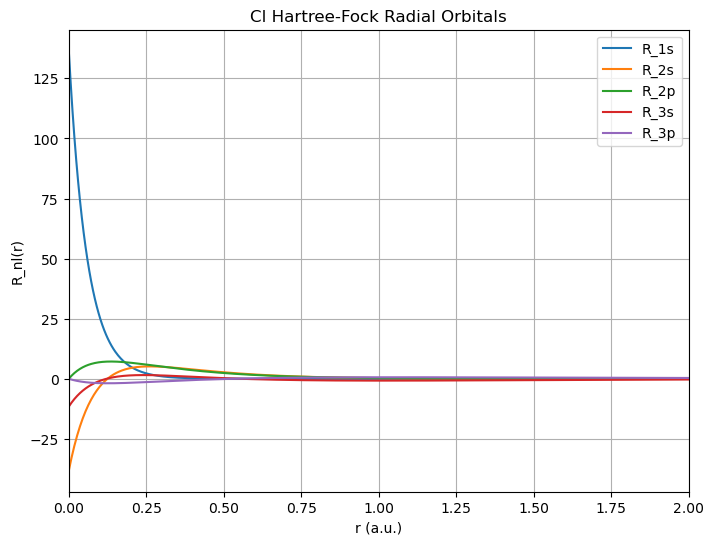

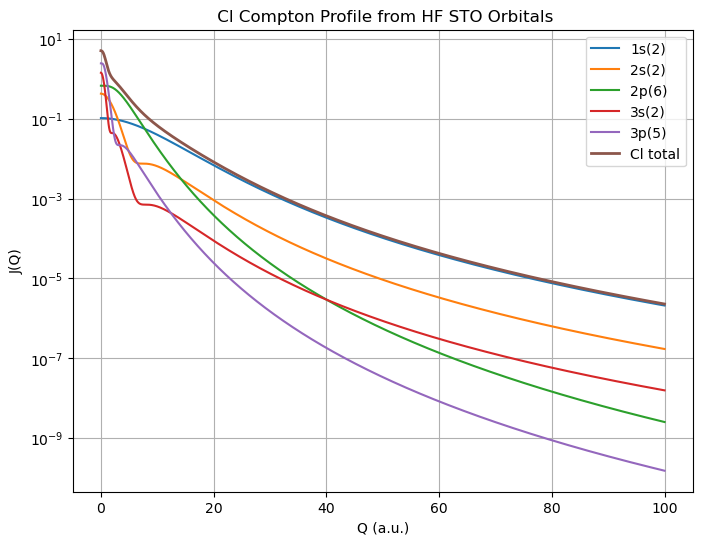

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Chlorine Hartree-Fock STO data
# Cl: 1s2 2s2 2p6 3s2 3p5
# Ground term: 2P
# Format: (n_j, Z_j, C_j)
# =====================================================

chlorine_1s = [
    (1, 23.7918,  0.357615),
    (1, 14.4872,  0.484997),
    (2, 20.8326,  0.187615),
    (2,  9.4342, -0.000352),
    (2,  6.4160,  0.002796),
    (2,  4.7671, -0.001073),
    (3, 44.4484, -0.000427),
    (3,  3.5704,  0.000168),
    (3,  2.3743, -0.000089),
    (3,  1.6610,  0.000017),
]

chlorine_2s = [
    (1, 23.7918,  0.072699),
    (1, 14.4872, -0.499909),
    (2, 20.8326,  0.056841),
    (2,  9.4342,  0.013158),
    (2,  6.4160,  0.883708),
    (2,  4.7671,  0.214427),
    (3, 44.4484,  0.000223),
    (3,  3.5704, -0.001859),
    (3,  2.3743,  0.002000),
    (3,  1.6610,  0.000024),
]

chlorine_3s = [
    (1, 23.7918,  0.032061),
    (1, 14.4872, -0.172436),
    (2, 20.8326,  0.024503),
    (2,  9.4342,  0.018179),
    (2,  6.4160,  0.140693),
    (2,  4.7671,  0.342425),
    (3, 44.4484,  0.000064),
    (3,  3.5704, -0.353160),
    (3,  2.3743, -0.600895),
    (3,  1.6610, -0.254301),
]

chlorine_2p = [
    (2, 24.4396, -0.001409),
    (2, 11.4909,  0.129060),
    (2,  6.6724,  0.511775),
    (2,  4.8559,  0.404231),
    (3, 18.9808, -0.007959),
    (3,  2.9926,  0.004770),
    (3,  1.8970,  0.000703),
    (3,  1.2586,  0.000479),
]

chlorine_3p = [
    (2, 24.4396,  0.001525),
    (2, 11.4909, -0.045154),
    (2,  6.6724, -0.095725),
    (2,  4.8559, -0.176763),
    (3, 18.9808,  0.005308),
    (3,  2.9926,  0.354699),
    (3,  1.8970,  0.523394),
    (3,  1.2586,  0.257066),
]
# =====================================================
# HF normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================
def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 1000.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Krypton radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
        elif n == 4:
            print(f"{A:+.4f} * r^3 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, chlorine_1s)
R2s = R_nl(r, chlorine_2s)
R3s = R_nl(r, chlorine_3s)

R2p = R_nl(r, chlorine_2p)
R3p = R_nl(r, chlorine_3p)

print_R_formula(chlorine_1s, "Cl_R1s")
print_R_formula(chlorine_2s, "Cl_R2s")
print_R_formula(chlorine_3s, "Cl_R3s")

print_R_formula(chlorine_2p, "Cl_R2p")
print_R_formula(chlorine_3p, "Cl_R3p")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_3s = chi_p(p, r, R3s, l=0)

chi_2p = chi_p(p, r, R2p, l=1)
chi_3p = chi_p(p, r, R3p, l=1)

# =====================================================
# Momentum densities and Compton profiles
# =====================================================
I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_3s, J_3s = calculate_J(p, chi_3s, Q)

I_2p, J_2p = calculate_J(p, chi_2p, Q)
I_3p, J_3p = calculate_J(p, chi_3p, Q)

print("Norm 1s =", np.trapezoid(I_1s, p))
print("Norm 2s =", np.trapezoid(I_2s, p))
print("Norm 2p =", np.trapezoid(I_2p, p))
print("Norm 3s =", np.trapezoid(I_3s, p))
print("Norm 3p =", np.trapezoid(I_3p, p))

# Cl: 1s2 2s2 2p6 3s2 3p5
J_total = 2*J_1s + 2*J_2s + 6*J_2p + 2*J_3s + 5*J_3p 

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_3s_one_electron": J_3s,
    "J_2p_one_electron": J_2p,
    "J_3p_one_electron": J_3p,
    "J_total_Cl": J_total
    })
print(table)
table.to_csv("Cl_STO_HF_profile.csv", index = False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.plot(r, R3s, label="R_3s")
plt.plot(r, R3p, label="R_3p")
plt.xlim(0, 2)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Cl Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")
plt.plot(Q, 2*J_3s, label="3s(2)")
plt.plot(Q, 5*J_3p, label="3p(5)")

plt.plot(Q, J_total, label="Cl total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title(" Cl Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()